In [5]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, BertModel, BertTokenizerFast
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
print('Using device:', device)

# if using Google Colab, mount Google Drive
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    train_path = '/content/drive/MyDrive/CS5242Project/train_preprocessed.csv'
    test_path  = '/content/drive/MyDrive/CS5242Project/test_preprocessed.csv'
else:
    train_path = 'transformers_train_preprocessed.csv'
    test_path  = 'transformers_test_preprocessed.csv'

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

train['cleaned_text'] = train['Text']
test['cleaned_text'] = test['Text']
train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text']  = test['cleaned_text'].astype(str)

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train['Bias'])
y_test  = label_encoder.transform(test['Bias'])
num_classes = len(label_encoder.classes_)

tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        encodings = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encodings["input_ids"].squeeze(0),
            "attention_mask": encodings["attention_mask"].squeeze(0),
            "labels": torch.tensor(label)
        }

Using device: cuda


In [6]:
train_dataset = NewsDataset(train['cleaned_text'], y_train, tokenizer)
test_dataset = NewsDataset(test['cleaned_text'], y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

In [7]:
from transformers import BertModel, BertForSequenceClassification
from torch import nn

class Bert(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)
        self.tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        outputs = self.bert(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, return_dict=True)
        pooled = outputs.pooler_output
        logits = self.classifier(pooled)
        return logits

In [19]:
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import time
import io
import torch

model = Bert(num_labels=num_classes)
model.to(device)

optimizer = AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)
num_epochs = 30
total_steps = len(train_loader) * num_epochs
warmup_steps = int(0.1 * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

bad_epochs = [0] * num_epochs
patience = 3
best_score = None
model_name = 'bert'
fpath = f'{model_name}.pt'
if 'google.colab' in sys.modules:
    fpath = os.path.join('/content/drive/My Drive', fpath)

min_delta = 0.0
lrs = []

# 6. Training & evaluation loop
for epoch in range(num_epochs):
    s = time.time()
    # — Training
    model.train()
    total_train_loss = 0
    for batch in train_loader:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        logits = model(input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)

        # Backward pass
        loss.backward()
        optimizer.step()
        scheduler.step()
        lrs.append(scheduler.get_lr())

        optimizer.zero_grad()

        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch+1} →  training loss: {avg_train_loss:.4f}")

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids     = batch["input_ids"].to(device)
            attention_mask= batch["attention_mask"].to(device)
            labels        = batch["labels"].to(device)

            logits = model(input_ids, attention_mask=attention_mask)
            preds  = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    print(f"Epoch {epoch+1} — Eval accuracy: {acc:.4f}; F1: {f1:.4f}; Precision: {precision:.4f}; Recall: {recall:.4f}; Time: {time.time() - s}")

    # early stopping
    score = acc
    if best_score is None or (score - best_score) > min_delta:
        best_score = score
        torch.save(model.state_dict(), fpath)
    else:
        bad_epochs[epoch] = 1
        if epoch - 1 > patience and all(bad_epochs[epoch-patience: epoch]):
            print(f"No improvement for {patience} epochs, stopping early")
            break

state_dict = torch.load(fpath)
os.remove(fpath)
model.load_state_dict(state_dict)

Epoch 1 →  training loss: 1.5677
Epoch 1 — Eval accuracy: 0.4508; F1: 0.4592; Precision: 0.5637; Recall: 0.4508; Time: 31.24130606651306
Epoch 2 →  training loss: 1.2785


/home/ben/.virtualenvs/CS5242Project/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 2 — Eval accuracy: 0.5011; F1: 0.5037; Precision: 0.6394; Recall: 0.5011; Time: 31.35731291770935
Epoch 3 →  training loss: 1.1393
Epoch 3 — Eval accuracy: 0.5698; F1: 0.5828; Precision: 0.6281; Recall: 0.5698; Time: 31.39376163482666
Epoch 4 →  training loss: 0.9670
Epoch 4 — Eval accuracy: 0.5904; F1: 0.5982; Precision: 0.6171; Recall: 0.5904; Time: 31.152568101882935
Epoch 5 →  training loss: 0.7551
Epoch 5 — Eval accuracy: 0.5240; F1: 0.5506; Precision: 0.6319; Recall: 0.5240; Time: 31.119288206100464
Epoch 6 →  training loss: 0.5026
Epoch 6 — Eval accuracy: 0.5744; F1: 0.5864; Precision: 0.6695; Recall: 0.5744; Time: 31.147002935409546
Epoch 7 →  training loss: 0.3382
Epoch 7 — Eval accuracy: 0.6384; F1: 0.6214; Precision: 0.6332; Recall: 0.6384; Time: 31.175779581069946
Epoch 8 →  training loss: 0.2385
Epoch 8 — Eval accuracy: 0.6362; F1: 0.6342; Precision: 0.6557; Recall: 0.6362; Time: 31.475829362869263
Epoch 9 →  training loss: 0.1543
Epoch 9 — Eval accuracy: 0.6339; F1:

<All keys matched successfully>

In [21]:
# from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

      center       0.52      0.32      0.39        41
   lean left       0.46      0.48      0.47        61
  lean right       0.41      0.35      0.38        37
        left       0.78      0.77      0.78       222
       right       0.49      0.64      0.56        76

    accuracy                           0.63       437
   macro avg       0.53      0.51      0.52       437
weighted avg       0.63      0.63      0.63       437



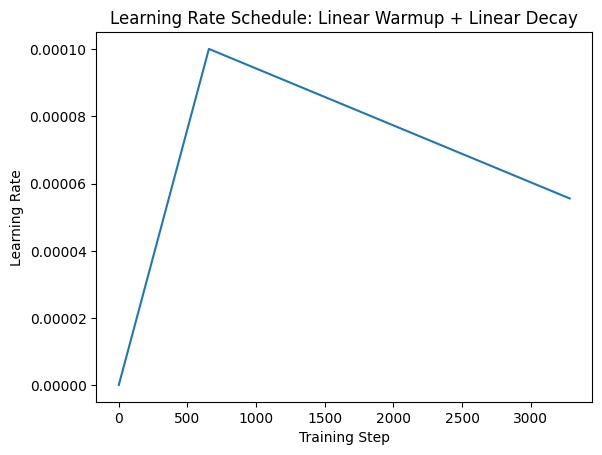

In [26]:
# plot learning rate schedule
plt.plot(range(len(lrs)), lrs)
plt.title("Learning Rate Schedule: Linear Warmup + Linear Decay")
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.show()

In [28]:
from transformers import get_cosine_schedule_with_warmup
#try a cosine schedule
model = Bert(num_labels=num_classes)
model.to(device)

optimizer = AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)
num_epochs = 30
total_steps = len(train_loader) * num_epochs
warmup_steps = int(0.1 * total_steps)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

bad_epochs = [0] * num_epochs
patience = 3
best_score = None
model_name = 'bert'
fpath = f'{model_name}.pt'
if 'google.colab' in sys.modules:
    fpath = os.path.join('/content/drive/My Drive', fpath)

min_delta = 0.0
lrs = []

# 6. Training & evaluation loop
for epoch in range(num_epochs):
    s = time.time()
    # — Training
    model.train()
    total_train_loss = 0
    for batch in train_loader:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        logits = model(input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)

        # Backward pass
        loss.backward()
        optimizer.step()
        scheduler.step()
        lrs.append(scheduler.get_lr())

        optimizer.zero_grad()

        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch+1} →  training loss: {avg_train_loss:.4f}")

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids     = batch["input_ids"].to(device)
            attention_mask= batch["attention_mask"].to(device)
            labels        = batch["labels"].to(device)

            logits = model(input_ids, attention_mask=attention_mask)
            preds  = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    print(f"Epoch {epoch+1} — Eval accuracy: {acc:.4f}; F1: {f1:.4f}; Precision: {precision:.4f}; Recall: {recall:.4f}; Time: {time.time() - s}")

    # early stopping
    score = acc
    if best_score is None or (score - best_score) > min_delta:
        best_score = score
        torch.save(model.state_dict(), fpath)
    else:
        bad_epochs[epoch] = 1
        if epoch - 1 > patience and all(bad_epochs[epoch-patience: epoch]):
            print(f"No improvement for {patience} epochs, stopping early")
            break

state_dict = torch.load(fpath)
os.remove(fpath)
model.load_state_dict(state_dict)

Epoch 1 →  training loss: 1.5495


/home/ben/.virtualenvs/CS5242Project/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1 — Eval accuracy: 0.4233; F1: 0.4121; Precision: 0.5021; Recall: 0.4233; Time: 31.321743726730347
Epoch 2 →  training loss: 1.2701
Epoch 2 — Eval accuracy: 0.5057; F1: 0.5134; Precision: 0.7496; Recall: 0.5057; Time: 31.47795796394348
Epoch 3 →  training loss: 1.1607
Epoch 3 — Eval accuracy: 0.5584; F1: 0.5541; Precision: 0.6189; Recall: 0.5584; Time: 31.3955180644989
Epoch 4 →  training loss: 1.1715
Epoch 4 — Eval accuracy: 0.5263; F1: 0.5488; Precision: 0.6716; Recall: 0.5263; Time: 31.348944187164307
Epoch 5 →  training loss: 0.8852
Epoch 5 — Eval accuracy: 0.5584; F1: 0.5767; Precision: 0.6701; Recall: 0.5584; Time: 31.36754035949707
Epoch 6 →  training loss: 0.7027
Epoch 6 — Eval accuracy: 0.6041; F1: 0.5889; Precision: 0.5933; Recall: 0.6041; Time: 31.38985800743103
Epoch 7 →  training loss: 0.3884
Epoch 7 — Eval accuracy: 0.6476; F1: 0.6316; Precision: 0.6737; Recall: 0.6476; Time: 31.36216902732849
Epoch 8 →  training loss: 0.3458
Epoch 8 — Eval accuracy: 0.5240; F1: 0.5

<All keys matched successfully>

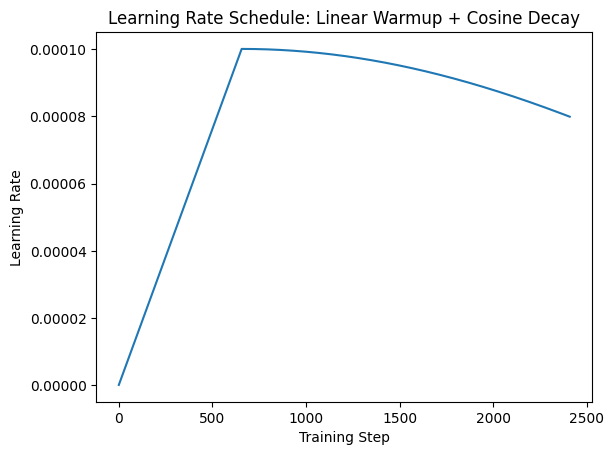

In [31]:
# plot learning rate schedule
plt.plot(range(len(lrs)), lrs)
plt.title("Learning Rate Schedule: Linear Warmup + Cosine Decay")
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.show()